In [16]:
# Qiskit 1.02 used for Aer V1 Sampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_algorithms import QAOA, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization import QuadraticProgram
from qiskit.primitives import StatevectorSampler
from qiskit_optimization.converters import IntegerToBinary
import json
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

In [17]:


# 1. Define the frequency grid and filter specifications
omegas = np.linspace(0, np.pi, 50) # 50 points from 0 to Nyquist frequency
cutoff = 0.1 * np.pi
stop_start = 0.5 * np.pi

# We will collect the valid points, targets (D), and weights (W)
valid_omegas, targets, weights = [], [], []

for w in omegas:
    if w <= cutoff:
        valid_omegas.append(w) # Ignore w in the transition band
        targets.append(1.0)  # Passband ideal filter is 1
        weights.append(1.0)  # Passband weight
    elif w >= stop_start:
        valid_omegas.append(w) # Ignore w in the transition band
        targets.append(0.0)  # Stopband ideal filter is 0
        weights.append(1.0)  # Stopband weight

# 2. Initialize Matrices for the Objective Function
Q = np.zeros((4, 4)) # Quadratic coefficients
L = np.zeros(4)      # Linear coefficients

# Lower bound = -1.0, Upper bound = 1.0, B = 4 bits (0 to 15)
scale = 2.0 / 15.0   # The (U - L) / (2^B - 1) term for scaling integer variables to the filter coefficients
shift = -1.0         # The Lower Bound (L)

# 3. Calculate the Linear and Quadratic coefficients across the grid
for w, D_k, W_k in zip(valid_omegas, targets, weights):
    # The cosine vector for this specific frequency
    c_k = np.array([1, np.cos(w), np.cos(2*w), np.cos(3*w)])
    
    # Calculate the Constant chunk (K_k)
    K_k = shift * np.sum(c_k) - D_k
    
    # Accumulate Quadratic terms (outer product of c_k with itself)
    Q += W_k * (scale**2) * np.outer(c_k, c_k)
    
    # Accumulate Linear terms
    L += W_k * 2 * K_k * scale * c_k

# 4. Plug it into Qiskit
qp = QuadraticProgram()

# Define the 4 integer variables (0 to 15 represents 4 bits)
for i in range(4):
    qp.integer_var(lowerbound=0, upperbound=15, name=f'x{i}')

# Qiskit natively accepts NumPy matrices for the objective!
qp.minimize(linear=L, quadratic=Q)

# 5. Convert the Integer problem to a Binary QUBO for the Quantum Algorithm
converter = IntegerToBinary()
qubo_QP = converter.convert(qp)

print(f"Problem successfully built!")
print(f"Number of Continuous Integer Variables: {qp.get_num_vars()}")
print(f"Number of Binary Qubits for QAOA: {qubo_QP.get_num_vars()}")

Problem successfully built!
Number of Continuous Integer Variables: 4
Number of Binary Qubits for QAOA: 16


In [18]:
# 1. Initialize classical solver
exact_solver = NumPyMinimumEigensolver()

# 2. Wrap classical solver in opitimization module
exact_optimizer = MinimumEigenOptimizer(exact_solver)

# 3. Solve the QuadraticProgram (your discretized FIR QUBO)
exact_result = exact_optimizer.solve(qubo_QP)

# 5. Extract the important data points
optimal_bits = exact_result.x       # Returns a NumPy array of the optimal bitstring e.g., [1., 1., 0.]
optimal_cost = exact_result.fval    # Returns the objective function value (your minimum error)
opt_status = exact_result.status    # Returns an Enum indicating success/failure

# 6. Store the results in a dictionary for easy saving
saved_results = {
    "optimal_bitstring": [int(bit) for bit in optimal_bits], # Convert floats to ints for clean JSON
    "minimum_error": optimal_cost,
    "status": opt_status.name
}

print("Optimization Results:")
print(json.dumps(saved_results, indent=4))

Optimization Results:
{
    "optimal_bitstring": [
        0,
        1,
        0,
        1,
        1,
        1,
        0,
        1,
        1,
        0,
        0,
        1,
        0,
        0,
        0,
        1
    ],
    "minimum_error": -128.11658579643102,
    "status": "SUCCESS"
}


In [ ]:
from qiskit_aer.primitives import Sampler

# 1. Define the classical optimizer
optimizer = COBYLA(maxiter=100) 
# Classical optimizer, can swap out for SPSA (Simultaneous Perturbation Stochastic Approximation) 
# if you want a more "quantum-aware" optimizer that can handle noise "the quantum shots" better

# 2. Initialize the Sampler (quantum simulatorbackend)
sampler = Sampler(run_options={"shots": None})

# 3. Initialize QAOA
qaoa_solver = QAOA(sampler=sampler, optimizer=optimizer, reps=2)

# 4. Wrap and Solve
qaoa_optimizer = MinimumEigenOptimizer(qaoa_solver)
result = qaoa_optimizer.solve(qubo_QP)

print(result.prettyprint())

In [ ]:
# --- 1. THE DECODER ---
# Get the 4 optimized integer variables (0 to 15) from the quantum result
raw_integers = result.x 

# Use the exact scale and shift from your problem setup
scale = 2.0 / 15.0
shift = -1.0

# Decode integers back into continuous values (-1.0 to 1.0) from Quantum Approximation
A = [(val * scale) + shift for val in raw_integers]
print(f"Decoded Cosine Coefficients from Quantum Optimization: {A}")

# Decode values from Classical Optimization for comparison
exact_integers = exact_result.x
exact_A = [(val * scale) + shift for val in exact_integers]
print(f"Decoded Cosine Coefficients from Classical Optimization: {exact_A}")


# --- 2. THE 7-TAP MAPPER ---
h = np.zeros(7)
h_exact = np.zeros(7)

# Map the decoded values to the left side of the quantum filter
# Remember: The outer taps are divided by 2 because of the symmetry folding
h[3] = A[0]           # Center tap (corresponds to '1')
h[2] = A[1] / 2.0     # Corresponds to cos(w)
h[1] = A[2] / 2.0     # Corresponds to cos(2*w)
h[0] = A[3] / 2.0     # Corresponds to cos(3*w)

h_exact[3] = exact_A[0]           # Center tap (corresponds to '1')
h_exact[2] = exact_A[1] / 2.0     # Corresponds to cos(w)
h_exact[1] = exact_A[2] / 2.0     # Corresponds to cos(2*w)
h_exact[0] = exact_A[3] / 2.0     # Corresponds to cos(3*w)

# Mirror the left side to the right side to complete the Type I symmetry
h[4] = h[2]
h[5] = h[1]
h[6] = h[0]

h_exact[4] = h_exact[2]
h_exact[5] = h_exact[1]
h_exact[6] = h_exact[0]

print("\n--- FINAL QUANTUM FIR FILTER ---")
print(f"h[n] = {h}")

print("\n--- FINAL CLASSICAL FIR FILTER ---")
print(f"h[n] = {h_exact}")

Decoded Cosine Coefficients: [-0.8666666666666667, -0.8666666666666667, -1.0, -0.8666666666666667, -1.0, -1.0, -0.8666666666666667, -0.8666666666666667, -1.0, -1.0, -1.0, -0.8666666666666667, -1.0, -0.8666666666666667, -0.8666666666666667, -1.0]

--- FINAL QUANTUM FIR FILTER ---
h[n] = [-0.43333333 -0.5        -0.43333333 -0.86666667 -0.43333333 -0.5
 -0.43333333]


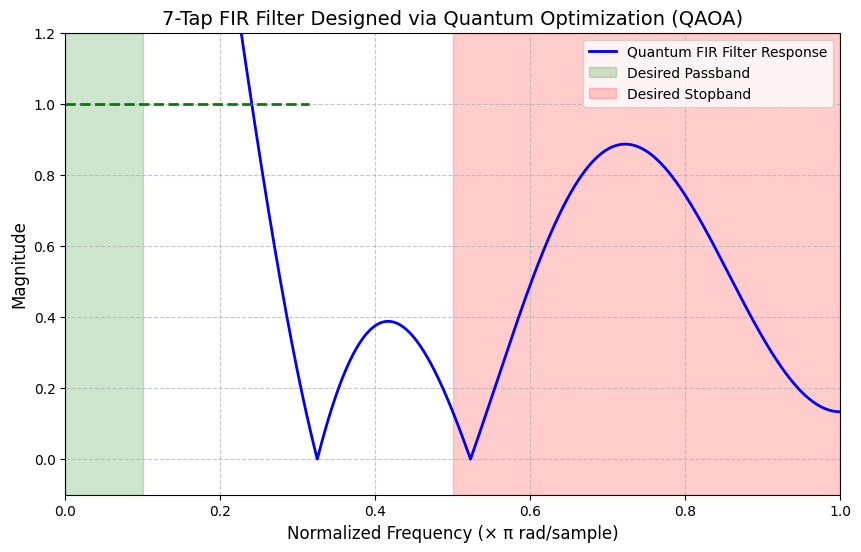

In [15]:
# 1. Calculate the frequency response
# freqz calculates the response given the filter coefficients (h)
# worN=8000 gives us a highly detailed, smooth curve
w, h_resp = freqz(h, worN=8000)

# Convert frequency from radians to normalized Nyquist (0 to 1.0)
normalized_freq = w / np.pi

# Calculate the Magnitude (Absolute value of the complex response)
magnitude = np.abs(h_resp)

# 2. Setup the Plot
plt.figure(figsize=(10, 6))
plt.plot(normalized_freq, magnitude, 'b-', label='Quantum FIR Filter Response', linewidth=2)

# 3. Draw your Target Specifications (from your first cell)
# Passband: 0 to 0.33 * pi
plt.axvspan(0, 0.1, color='green', alpha=0.2, label='Desired Passband')
plt.plot([0, 0.1 * np.pi], [1, 1], 'g--', linewidth=2) 

# Stopband: 0.5 * pi to pi
plt.axvspan(0.5, 1.0, color='red', alpha=0.2, label='Desired Stopband')
plt.plot([0.5 * np.pi, np.pi], [0, 0], 'r--', linewidth=2)

# 4. Format the chart nicely
plt.title('7-Tap FIR Filter Designed via Quantum Optimization (QAOA)', fontsize=14)
plt.xlabel('Normalized Frequency (\u00d7 \u03c0 rad/sample)', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.ylim([-0.1, 1.2])
plt.xlim([0, 1])

# Show the plot
plt.show()

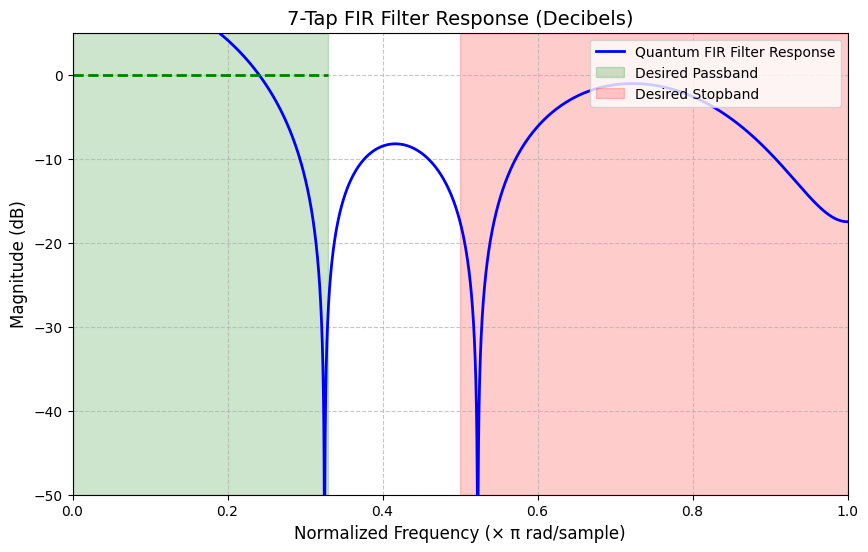

In [ ]:
# 1. Calculate the frequency response
w, h_resp = freqz(h, worN=8000)

# Convert frequency from radians to normalized Nyquist (0 to 1.0)
normalized_freq = w / np.pi

# Calculate the Magnitude (Absolute value of the complex response)
magnitude = np.abs(h_resp)

# Convert magnitude to Decibels (dB)
# We use np.maximum to prevent log(0) errors if the magnitude hits exactly 0
magnitude_db = 20 * np.log10(np.maximum(magnitude, 1e-10))

# 2. Setup the Plot
plt.figure(figsize=(10, 6))
plt.plot(normalized_freq, magnitude_db, 'b-', label='Quantum FIR Filter Response', linewidth=2)

# 3. Draw your Target Specifications 
# Passband: 0 to 0.33 * pi. Ideal passband is 1.0 magnitude, which is 0 dB.
plt.axvspan(0, 0.33, color='green', alpha=0.2, label='Desired Passband')
plt.plot([0, 0.33], [0, 0], 'g--', linewidth=2) # 0 dB line

# Stopband: 0.5 * pi to pi. Ideal stopband is 0 magnitude, which is -infinity dB.
# We shade the region to indicate where the suppression should occur.
plt.axvspan(0.5, 1.0, color='red', alpha=0.2, label='Desired Stopband')

# 4. Format the chart nicely for dB scale
plt.title('7-Tap FIR Filter Response (Decibels)', fontsize=14)
plt.xlabel('Normalized Frequency (\u00d7 \u03c0 rad/sample)', fontsize=12)
plt.ylabel('Magnitude (dB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Adjust Y-axis for dB (usually looking down to -40 or -60 dB for a short filter)
plt.ylim([-50, 5]) 
plt.xlim([0, 1])

# Show the plot
plt.show()